# 🤖 Máquina de Soporte Vectorial (SVM) — Dataset Iris
**Diplomado en Redes Neuronales y Deep Learning**

Este notebook cubre:
1. ¿Qué es una SVM y cómo funciona?
2. Carga del dataset y exploración
3. Preprocesamiento: Normalización y One-Hot Encoding
4. Reducción 4D → 2D para visualizar el hiperplano
5. Visualización de la frontera de decisión
6. Modelo completo con las 4 features
7. Comparativa de kernels
8. Predicción con flor nueva

---
## 🧠 1. ¿Qué es una SVM?

Una **Máquina de Soporte Vectorial** busca el **hiperplano** que mejor separa las clases, maximizando el **margen** entre ellas.

### Conceptos clave:

| Concepto | Qué es |
|---|---|
| **Hiperplano** | La 'línea' de separación (en 2D es una línea, en 3D un plano, en 4D un hiperplano) |
| **Margen** | La distancia entre el hiperplano y los puntos más cercanos de cada clase |
| **Vectores de soporte** | Los puntos de datos más cercanos al hiperplano — los que 'sostienen' el margen |
| **Kernel** | Truco matemático para manejar datos no separables linealmente |
| **C** | Parámetro de regularización: C alto = menos errores pero puede overfit |

### ¿Por qué 4D → 2D?
El dataset Iris tiene **4 features** (4 dimensiones). Los humanos no podemos visualizar 4D,
así que seleccionamos **2 features** para poder **graficar el hiperplano** y entender cómo trabaja la SVM.

---
## 📦 2. Importaciones y carga del dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Cargamos el dataset Iris (100 muestras, 4 features, 3 clases)
iris = load_iris()
X = iris.data          # Las 4 características (medidas de la flor)
y = iris.target        # La etiqueta (especie: 0=setosa, 1=versicolor, 2=virginica)

X = X[:100]
y = y[:100]

feature_names = iris.feature_names
class_names   = iris.target_names

# Convertimos a DataFrame para explorar mejor
df = pd.DataFrame(X, columns=feature_names)
df['especie'] = pd.Categorical.from_codes(y, class_names)

print(f"Total de muestras: {len(df)} (los 'primeros 100 datos')")
print(f"Features (dimensiones): {list(feature_names)}")
print(f"Clases: {list(class_names)}")
print()
display(df.head(8))

Total de muestras: 100 (los 'primeros 100 datos')
Features (dimensiones): ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Clases: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]



,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),especie
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa


---
## 🔧 3. Preprocesamiento

### ¿Por qué normalizar para SVM?

La SVM calcula **distancias** entre puntos para encontrar el margen máximo.
Si una feature va de 0 a 1000 y otra de 0 a 1, la primera dominaría el cálculo aunque no sea más importante.

**`StandardScaler`** transforma cada feature para que tenga:
- Media = 0
- Desviación estándar = 1

Fórmula: `X_scaled = (X - media) / desviación_estándar`

⚠️ **Regla importante**: Ajustar el scaler SOLO con datos de entrenamiento (`fit_transform`),
y aplicarlo a test sin reajustar (`transform`). Si usas datos de test para ajustar, hay **data leakage**.

In [3]:
# --- 3.1 División Train/Test ANTES de normalizar ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Train: {X_train.shape[0]} muestras | Test: {X_test.shape[0]} muestras")

# --- 3.2 Normalización con StandardScaler ---
scaler = StandardScaler()

# fit_transform: aprende la media/std del train Y transforma
X_train_scaled = scaler.fit_transform(X_train)

# transform: aplica la misma escala del train (sin reaprender)
X_test_scaled  = scaler.transform(X_test)

# Comparación antes vs después
print("\nAntes de normalizar (primeras 3 filas train):")
print(X_train[:3].round(3))
print("\nDespués de normalizar (mismas 3 filas):")
print(X_train_scaled[:3].round(3))
print("\nMedia después de escalar (debe ser ~0):", X_train_scaled.mean(axis=0).round(4))
print("Std  después de escalar (debe ser ~1):",  X_train_scaled.std(axis=0).round(4))

Train: 70 muestras | Test: 30 muestras

Antes de normalizar (primeras 3 filas train):
[[4.8 3.4 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [6.  3.4 4.5 1.6]]

Después de normalizar (mismas 3 filas):
[[-1.028  0.727 -0.926 -1.093]
 [-1.329  0.29  -1.069 -1.093]
 [ 0.775  0.727  1.14   1.428]]

Media después de escalar (debe ser ~0): [ 0.  0.  0. -0.]
Std  después de escalar (debe ser ~1): [1. 1. 1. 1.]


DataFrame con One-Hot Encoding:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),especie_setosa,especie_versicolor,especie_virginica
0,5.1,3.5,1.4,0.2,1,0,0
1,4.9,3.0,1.4,0.2,1,0,0
2,4.7,3.2,1.3,0.2,1,0,0
3,4.6,3.1,1.5,0.2,1,0,0
4,5.0,3.6,1.4,0.2,1,0,0
5,5.4,3.9,1.7,0.4,1,0,0


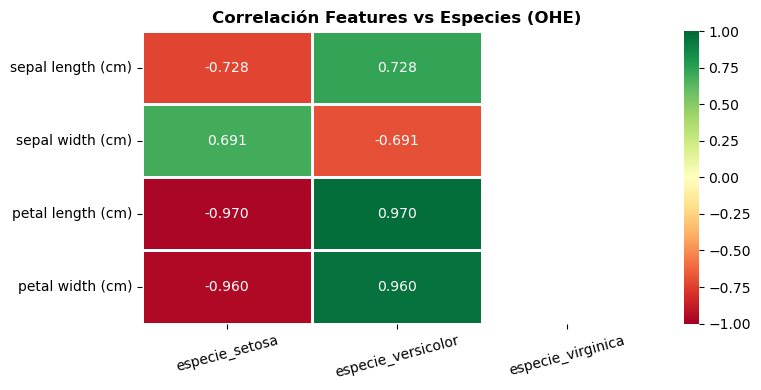


💡 petal length y petal width tienen mayor correlación con las especies.
   Las usaremos para la visualización 4D → 2D.


In [4]:
# --- 3.3 One-Hot Encoding de la especie (para análisis de correlación) ---
# Igual que en el notebook de árboles: convertimos la columna 'especie'
# en columnas binarias para poder calcular correlación numérica

df_ohe = pd.get_dummies(df, columns=['especie'], dtype=int)

print("DataFrame con One-Hot Encoding:")
display(df_ohe.head(6))

# Correlación features vs especies
corr = df_ohe.corr().round(3)
especies_ohe = ['especie_setosa', 'especie_versicolor', 'especie_virginica']
corr_feat_esp = corr.loc[feature_names, especies_ohe]

plt.figure(figsize=(8, 4))
sns.heatmap(corr_feat_esp, annot=True, fmt='.3f', cmap='RdYlGn',
            center=0, linewidths=1, vmin=-1, vmax=1)
plt.title('Correlación Features vs Especies (OHE)', fontsize=12, fontweight='bold')
plt.xticks(rotation=15)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n💡 petal length y petal width tienen mayor correlación con las especies.")
print("   Las usaremos para la visualización 4D → 2D.")

---
## 📉 4. Reducción 4D → 2D: selección de 2 features

Para **visualizar** el hiperplano (Kernel) necesitamos un espacio de 2 dimensiones.
Elegimos las 2 features con **mayor correlación** con las especies:
- **petal length (cm)** → índice 2
- **petal width (cm)**  → índice 3

Esto no es un modelo final, es solo para poder graficar y entender cómo funciona la SVM.

In [5]:
# --- 4.1 Seleccionamos las 2 features más discriminativas ---
FEAT_IDX = [2, 3]  # petal length y petal width
feat_2d  = [feature_names[i] for i in FEAT_IDX]

X_2d = X[:, FEAT_IDX]   # Solo 2 columnas de las 150 muestras

print(f"Forma original:    {X.shape}   (150 muestras, 4 features)")
print(f"Forma reducida 2D: {X_2d.shape} (150 muestras, 2 features)")
print(f"Features usadas:   {feat_2d}")

# División y normalización para el modelo 2D
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X_2d, y, test_size=0.3, random_state=42
)
scaler_2d = StandardScaler()
X2_train_s = scaler_2d.fit_transform(X2_train)
X2_test_s  = scaler_2d.transform(X2_test)

print(f"\nTrain 2D: {X2_train_s.shape} | Test 2D: {X2_test_s.shape}")

Forma original:    (100, 4)   (150 muestras, 4 features)
Forma reducida 2D: (100, 2) (150 muestras, 2 features)
Features usadas:   ['petal length (cm)', 'petal width (cm)']

Train 2D: (70, 2) | Test 2D: (30, 2)


---
## 🎯 5. Visualización de la Frontera de Decisión

La frontera de decisión es la **región** donde la SVM dice 'aquí cambia la clase'.
En 2D podemos pintarla como un mapa de colores.
Los **vectores de soporte** son los puntos con borde negro — los más cercanos a la frontera.

In [6]:
# --- 5.1 Entrenamos la SVM 2D con kernel lineal ---
svm_2d = SVC(kernel='linear', C=1.0, random_state=42)
svm_2d.fit(X2_train_s, y2_train)

acc_2d = svm_2d.score(X2_test_s, y2_test)
print(f"SVM 2D (kernel=linear) — Precisión test: {acc_2d*100:.2f}%")
print(f"Vectores de soporte por clase: {svm_2d.n_support_}")
print(f"  {class_names[0]}: {svm_2d.n_support_[0]} vectores")
print(f"  {class_names[1]}: {svm_2d.n_support_[1]} vectores")
print(f"  {class_names[2]}: {svm_2d.n_support_[2]} vectores")

SVM 2D (kernel=linear) — Precisión test: 100.00%
Vectores de soporte por clase: [2 2]
  setosa: 2 vectores
  versicolor: 2 vectores


IndexError: index 2 is out of bounds for axis 0 with size 2

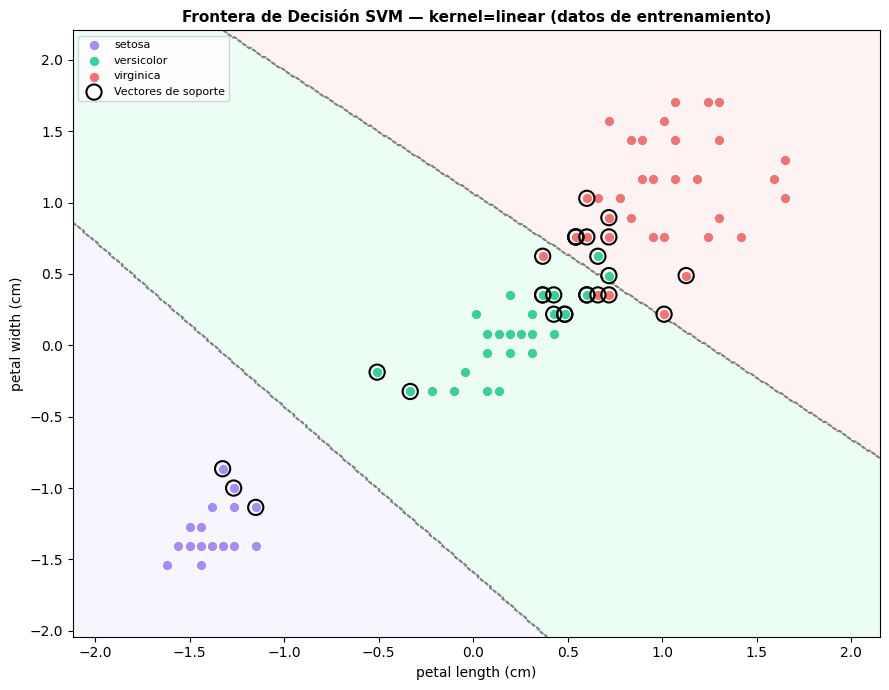

💡 ¿Qué estamos viendo?
   - Cada color de fondo = región donde la SVM clasifica esa especie
   - Los puntos coloreados = muestras reales de entrenamiento
   - Los puntos con borde negro = vectores de soporte (los más cercanos a la frontera)
   - La línea punteada gris = frontera de decisión (el hiperplano en 2D)


In [ ]:
# --- 5.2 Función para visualizar la frontera de decisión ---
def plot_decision_boundary(modelo, X_scaled, y, feat_names, titulo, ax):
    """Dibuja la frontera de decisión de un modelo SVM en 2D."""
    colores   = ['#a78bfa', '#34d399', '#f87171']  # violeta, verde, rojo
    colores_f = ['#ede9fe', '#d1fae5', '#fee2e2']  # versiones pálidas para el fondo

    # Creamos una malla de puntos que cubre todo el espacio
    x_min, x_max = X_scaled[:, 0].min() - 0.5, X_scaled[:, 0].max() + 0.5
    y_min, y_max = X_scaled[:, 1].min() - 0.5, X_scaled[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 400),
        np.linspace(y_min, y_max, 400)
    )

    # Predecimos la clase para cada punto de la malla
    Z = modelo.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    # Pintamos el fondo según la clase predicha
    from matplotlib.colors import ListedColormap
    cmap_fondo = ListedColormap(colores_f)
    ax.contourf(xx, yy, Z, alpha=0.4, cmap=cmap_fondo)
    ax.contour(xx, yy, Z, colors='gray', linewidths=0.8, linestyles='--')

    # Pintamos los puntos de datos
    for i, (nombre, color) in enumerate(zip(class_names, colores)):
        mask = y == i
        ax.scatter(X_scaled[mask, 0], X_scaled[mask, 1],
                   c=color, label=nombre, edgecolors='white',
                   s=60, zorder=3)

    # Marcamos los vectores de soporte (borde negro grueso)
    sv = modelo.support_vectors_
    ax.scatter(sv[:, 0], sv[:, 1],
               s=120, facecolors='none', edgecolors='black',
               linewidths=1.5, zorder=4, label='Vectores de soporte')

    ax.set_xlabel(feat_names[0], fontsize=10)
    ax.set_ylabel(feat_names[1], fontsize=10)
    ax.set_title(titulo, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8, loc='upper left')

# --- Graficamos ---
fig, ax = plt.subplots(figsize=(9, 7))
plot_decision_boundary(svm_2d, X2_train_s, y2_train, feat_2d,
                       'Frontera de Decisión SVM — kernel=linear (datos de entrenamiento)', ax)
plt.tight_layout()
plt.show()

print("💡 ¿Qué estamos viendo?")
print("   - Cada color de fondo = región donde la SVM clasifica esa especie")
print("   - Los puntos coloreados = muestras reales de entrenamiento")
print("   - Los puntos con borde negro = vectores de soporte (los más cercanos a la frontera)")
print("   - La línea punteada gris = frontera de decisión (el hiperplano en 2D)")

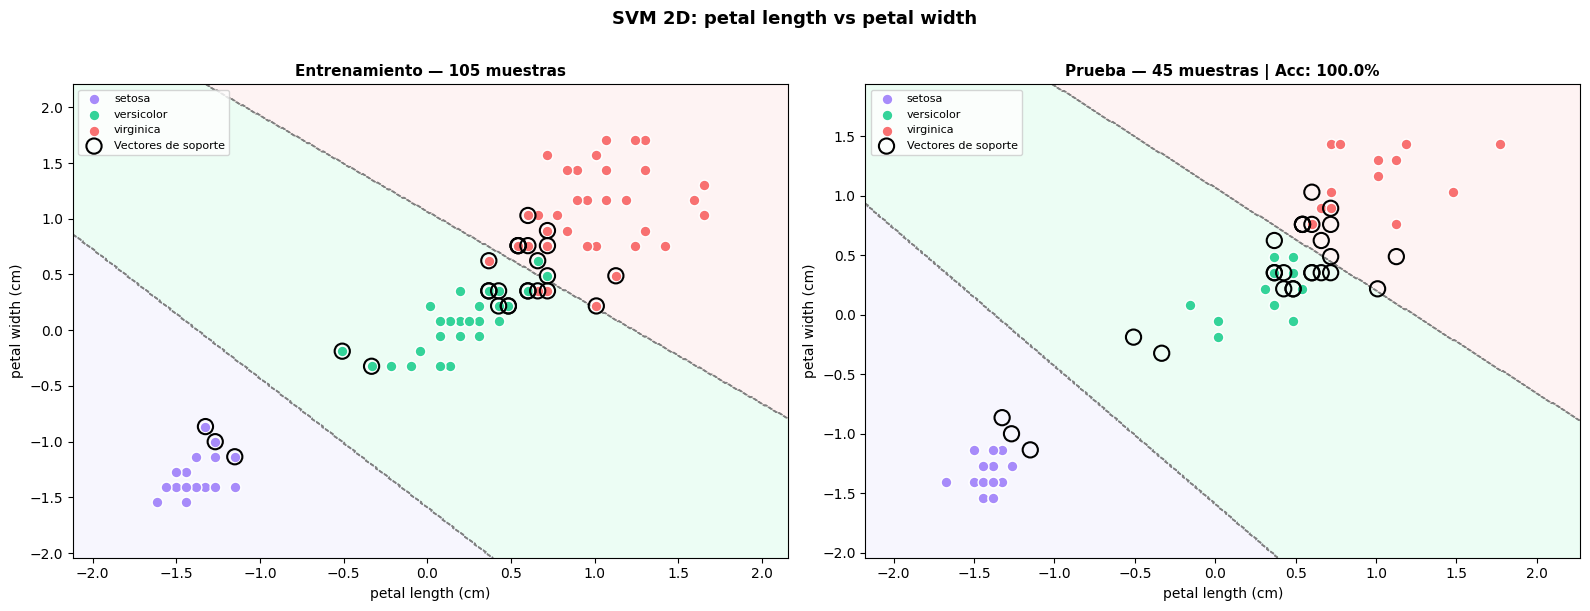

💡 Si los puntos del test también caen mayormente en la región correcta → el modelo generalizó bien.


In [ ]:
# --- 5.3 Comparativa visual: train vs test ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_decision_boundary(svm_2d, X2_train_s, y2_train, feat_2d,
                       f'Entrenamiento — {len(X2_train_s)} muestras', axes[0])
plot_decision_boundary(svm_2d, X2_test_s, y2_test, feat_2d,
                       f'Prueba — {len(X2_test_s)} muestras | Acc: {acc_2d*100:.1f}%', axes[1])

plt.suptitle('SVM 2D: petal length vs petal width', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("💡 Si los puntos del test también caen mayormente en la región correcta → el modelo generalizó bien.")

---
## 🌐 6. Modelo completo con las 4 features

Ahora usamos las 4 features (el espacio 4D real). Ya no podemos graficarlo,
pero es el modelo más preciso porque usa toda la información disponible.

In [ ]:
# --- 6.1 SVM completa con kernel lineal ---
modelo_svm = SVC(kernel='linear', C=1.0, random_state=42)
modelo_svm.fit(X_train_scaled, y_train)

predicciones_svm = modelo_svm.predict(X_test_scaled)
acc_full = accuracy_score(y_test, predicciones_svm)

print("=" * 55)
print("  REPORTE DE RENDIMIENTO — SVM 4D (kernel=linear)")
print("=" * 55)
print(classification_report(y_test, predicciones_svm, target_names=class_names))

print("\n💡 Interpretación del reporte:")
print("   precision: de los que predijo como X, ¿cuántos eran realmente X?")
print("   recall:    de los que realmente son X, ¿cuántos encontró?")
print("   f1-score:  media entre precision y recall (balance general)")
print("   support:   cuántas muestras reales hay de esa clase en test")

  REPORTE DE RENDIMIENTO — SVM 4D (kernel=linear)
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      0.92      0.96        13
   virginica       0.93      1.00      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45


💡 Interpretación del reporte:
   precision: de los que predijo como X, ¿cuántos eran realmente X?
   recall:    de los que realmente son X, ¿cuántos encontró?
   f1-score:  media entre precision y recall (balance general)
   support:   cuántas muestras reales hay de esa clase en test


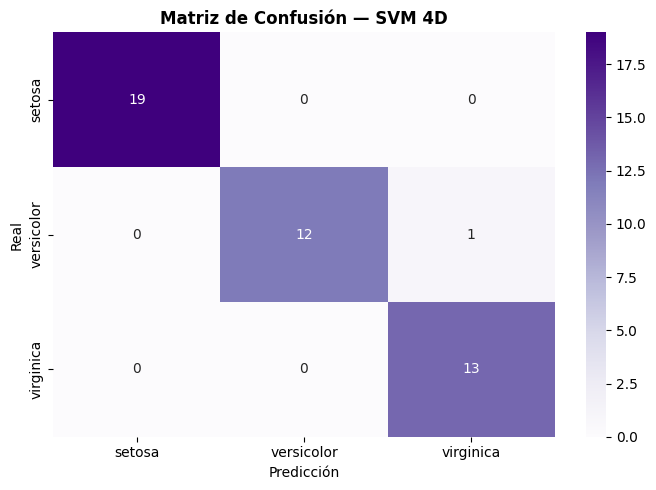

💡 La diagonal principal = predicciones correctas.
   Números fuera de la diagonal = errores del modelo.


In [ ]:
# --- 6.2 Matriz de confusión ---
cm = confusion_matrix(y_test, predicciones_svm)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión — SVM 4D', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("💡 La diagonal principal = predicciones correctas.")
print("   Números fuera de la diagonal = errores del modelo.")

---
## 🔄 7. Comparativa de Kernels

El **kernel** define cómo la SVM transforma el espacio para separar los datos.

| Kernel | Qué hace | Cuándo usarlo |
|---|---|---|
| `linear` | Hiperplano recto | Datos linealmente separables |
| `rbf` | Curvas gaussianas | Datos no lineales (más común en la práctica) |
| `poly` | Curvas polinomiales | Relaciones más complejas |

Vamos a comparar los 3 visualmente en 2D y ver cuál separa mejor.

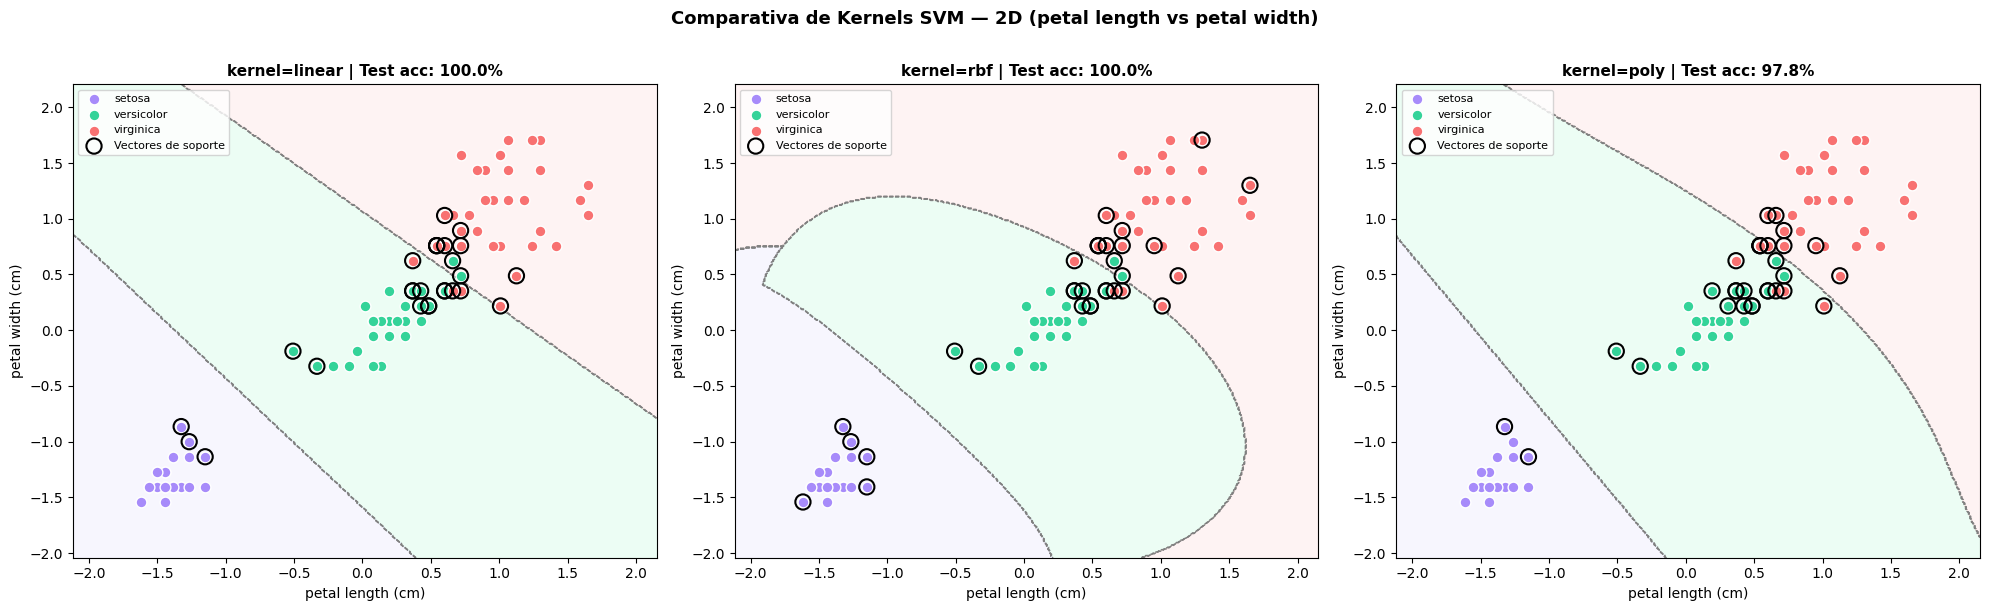

In [ ]:
# --- 7.1 Comparativa visual de kernels en 2D ---
kernels = [
    ('linear', {'kernel': 'linear', 'C': 1.0}),
    ('rbf',    {'kernel': 'rbf',    'C': 1.0, 'gamma': 'scale'}),
    ('poly',   {'kernel': 'poly',   'C': 1.0, 'degree': 3}),
]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (nombre, params) in zip(axes, kernels):
    svm_k = SVC(**params, random_state=42)
    svm_k.fit(X2_train_s, y2_train)
    acc_k = svm_k.score(X2_test_s, y2_test)
    plot_decision_boundary(
        svm_k, X2_train_s, y2_train, feat_2d,
        f'kernel={nombre} | Test acc: {acc_k*100:.1f}%', ax
    )

plt.suptitle('Comparativa de Kernels SVM — 2D (petal length vs petal width)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# --- 7.2 Comparativa numérica: 2D vs 4D por kernel ---
print(f"{'Kernel':<10} {'Acc 2D':>10} {'Acc 4D':>10} {'n_support':>15}")
print("-" * 48)

for nombre, params in kernels:
    # Modelo 2D
    m2 = SVC(**params, random_state=42).fit(X2_train_s, y2_train)
    a2 = m2.score(X2_test_s, y2_test)
    # Modelo 4D
    m4 = SVC(**params, random_state=42).fit(X_train_scaled, y_train)
    a4 = m4.score(X_test_scaled, y_test)

    print(f"{nombre:<10} {a2*100:>9.2f}% {a4*100:>9.2f}% {str(m4.n_support_):>15}")

print("\n💡 Observaciones:")
print("   - El modelo 4D siempre tiene mejor o igual precisión que el 2D")
print("     porque usa más información para clasificar.")
print("   - rbf suele ser el más robusto para datos del mundo real.")
print("   - n_support = cuántos vectores de soporte hay por clase.")

Kernel         Acc 2D     Acc 4D       n_support
------------------------------------------------
linear        100.00%     97.78%      [ 2 13 11]
rbf           100.00%    100.00%      [ 7 19 17]
poly           97.78%     95.56%      [ 5 22 20]

💡 Observaciones:
   - El modelo 4D siempre tiene mejor o igual precisión que el 2D
     porque usa más información para clasificar.
   - rbf suele ser el más robusto para datos del mundo real.
   - n_support = cuántos vectores de soporte hay por clase.


---
## 🌸 8. Predicción con flor nueva

Como en el notebook del profe: le damos medidas de una flor desconocida
y el modelo predice a qué especie pertenece.

In [ ]:
# --- 8.1 Flor del profe ---
# Formato: [sepal_length, sepal_width, petal_length, petal_width]
florNueva = [[1.0, 1.0, 1.5, 1.0]]

# ⚠️ IMPORTANTE: normalizar con el mismo scaler que usamos para entrenar
florNueva_scaled = scaler.transform(florNueva)

prediccion = modelo_svm.predict(florNueva_scaled)
print(f"Medidas de la flor nueva: sepal_length=1.0, sepal_width=1.0, petal_length=1.5, petal_width=1.0")
print(f"\nLa SVM predice que la flor es: [{prediccion[0]}] → '{class_names[prediccion[0]]}'")

Medidas de la flor nueva: sepal_length=1.0, sepal_width=1.0, petal_length=1.5, petal_width=1.0

La SVM predice que la flor es: [0] → 'setosa'


In [ ]:
# --- 8.2 Probar con más flores ---
flores_prueba = [
    [5.1, 3.5, 1.4, 0.2],  # Medidas típicas de Setosa
    [6.0, 2.9, 4.5, 1.5],  # Medidas típicas de Versicolor
    [6.7, 3.1, 5.6, 2.4],  # Medidas típicas de Virginica
    [1.0, 1.0, 1.5, 1.0],  # La del profe
]

flores_scaled = scaler.transform(flores_prueba)
predicciones  = modelo_svm.predict(flores_scaled)

print("Predicciones para múltiples flores:")
print(f"{'Medidas':<35} {'Pred':>5} {'Especie':<15}")
print("-" * 58)
for flor, pred in zip(flores_prueba, predicciones):
    print(f"{str(flor):<35} [{pred}]   {class_names[pred]}")

Predicciones para múltiples flores:
Medidas                              Pred Especie        
----------------------------------------------------------
[5.1, 3.5, 1.4, 0.2]                [0]   setosa
[6.0, 2.9, 4.5, 1.5]                [1]   versicolor
[6.7, 3.1, 5.6, 2.4]                [2]   virginica
[1.0, 1.0, 1.5, 1.0]                [0]   setosa


---
## 📝 9. Resumen: SVM vs Árbol de Decisión

| Característica | SVM | Árbol de Decisión |
|---|---|---|
| **¿Necesita normalizar?** | ✅ Sí (usa distancias) | ❌ No (usa reglas) |
| **¿Interpretable visualmente?** | Solo en 2D/3D | ✅ Siempre (árbol) |
| **Parámetro clave** | C (margen), kernel | max_depth |
| **Overfitting** | Menos propenso con C bajo | Propenso sin max_depth |
| **Con datos pequeños** | ✅ Funciona bien | ✅ Funciona bien |
| **Con datos grandes** | ⚠️ Lento | ✅ Rápido |

### ¿Por qué también veremos K-Means?
SVM y Árboles son **aprendizaje supervisado** (necesitan etiquetas).
**K-Means** es **aprendizaje no supervisado** — encuentra grupos sin saber las clases de antemano.
Es útil cuando no tienes datos etiquetados o quieres descubrir patrones ocultos.